# Employ Attrition Case Study

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

In [36]:
#!gdown 16KtxSt_QEGQvfluEaMls5cCHPwhRXgCk


In [37]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [38]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1. Exploratory Data Analysis (EDA)

In [39]:
# Basic dataset info
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum().sum())
print("\n" + "="*50)
print("Duplicate Rows:", df.duplicated().sum())
print("\n" + "="*50)
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (1470, 35)

Missing Values:
0

Duplicate Rows: 0


Basic Statistics:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


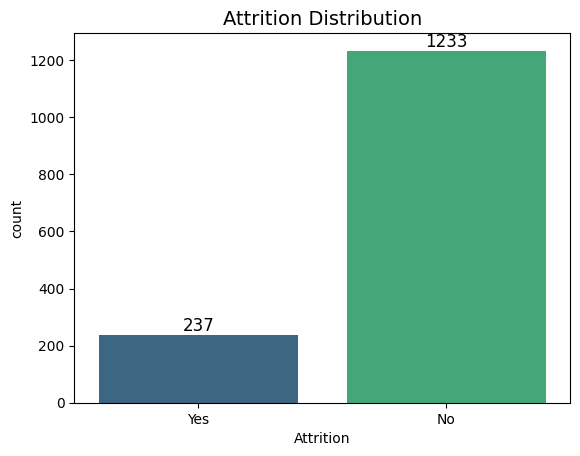


Attrition Rate: 16.12% (Imbalanced dataset!)


In [106]:
# Target Variable Distribution
import seaborn as sns

ax = sns.countplot(x='Attrition', data=df, palette='viridis')
ax.set_title('Attrition Distribution', fontsize=14)
ax.bar_label(ax.containers[0], fontsize=12)
ax.bar_label(ax.containers[1], fontsize=12)

plt.show()

attrition_rate = df['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}% (Imbalanced dataset!)")

In [67]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical Columns ({len(numerical_cols)}): {numerical_cols}")

Categorical Columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical Columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


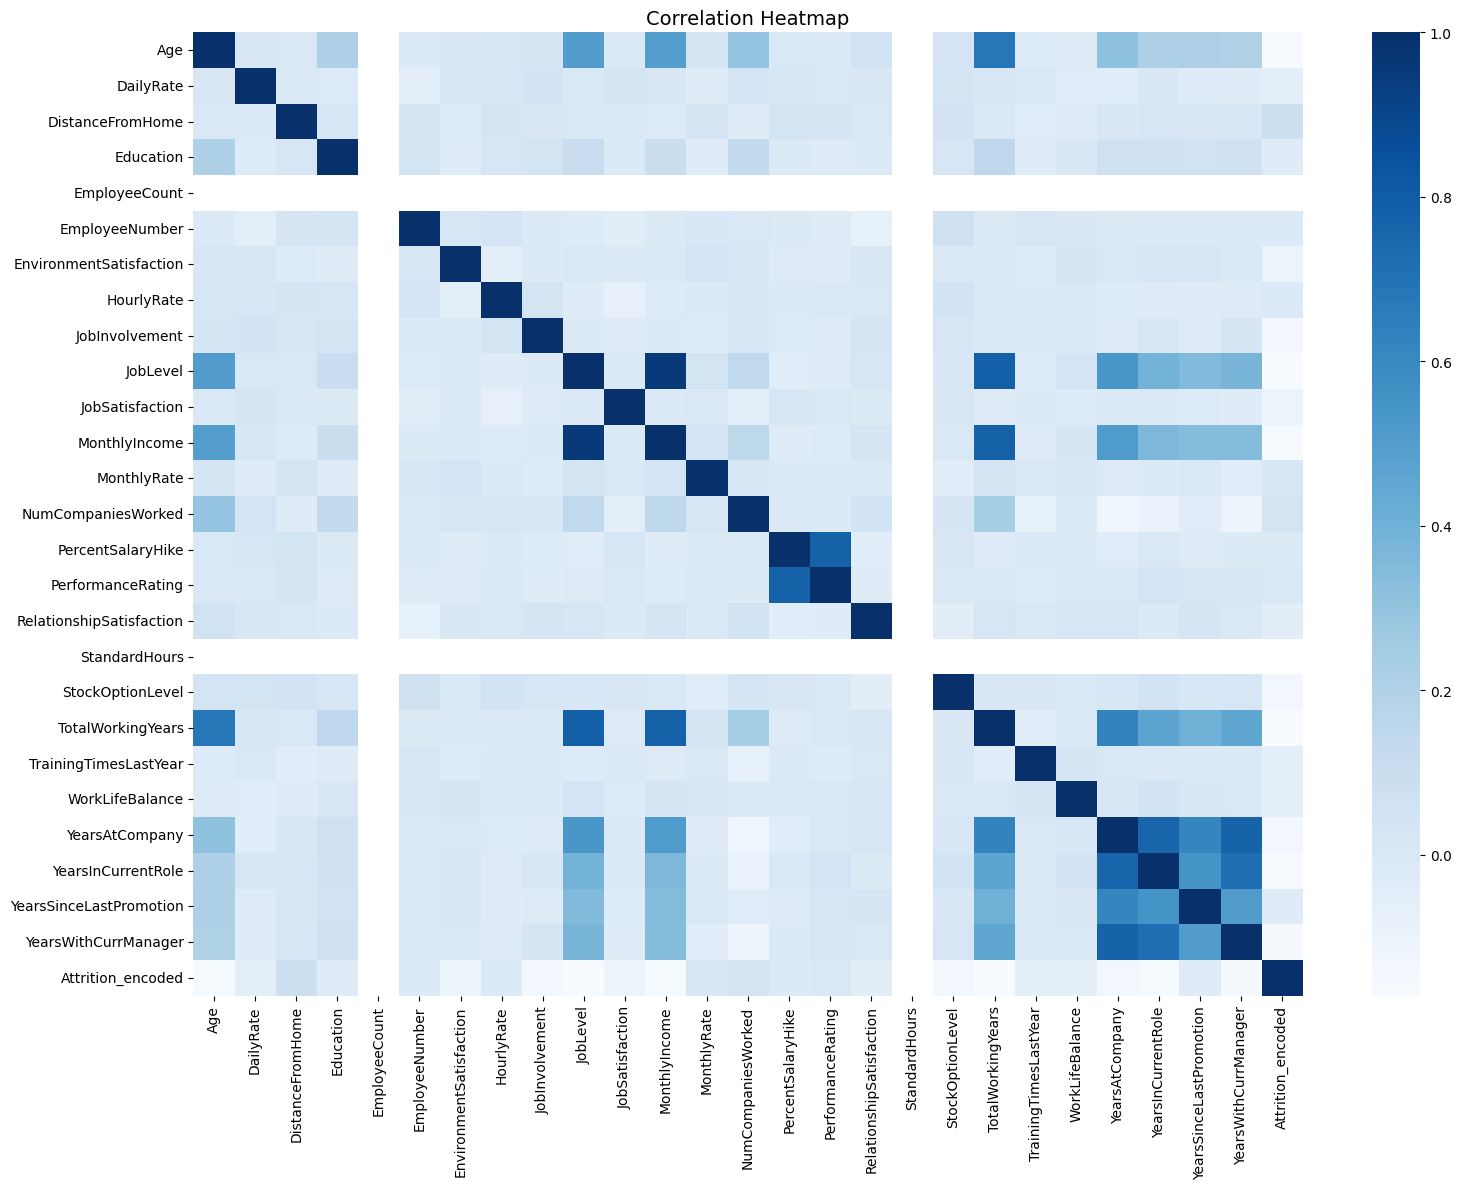


Top Correlations with Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_encoded, dtype: float64


In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))

# Create a copy with encoded target
df_corr = df.copy()
df_corr['Attrition_encoded'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

# Select only numerical columns for correlation
corr_matrix = df_corr[numerical_cols + ['Attrition_encoded']].corr()

# Plot heatmap

sns.heatmap(corr_matrix, annot=False, cmap='Blues')
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


In [72]:
# Check for constant/low-variance columns
print("Checking for constant columns:")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  - {col}: Only 1 unique value -> {df[col].unique()}")
    elif df[col].nunique() <= 2:
        print(f"  - {col}: {df[col].nunique()} unique values -> {df[col].unique()}")

Checking for constant columns:
  - Attrition: 2 unique values -> ['Yes' 'No']
  - EmployeeCount: Only 1 unique value -> [1]
  - Gender: 2 unique values -> ['Female' 'Male']
  - Over18: Only 1 unique value -> ['Y']
  - OverTime: 2 unique values -> ['Yes' 'No']
  - PerformanceRating: 2 unique values -> [3 4]
  - StandardHours: Only 1 unique value -> [80]


## 2. Data Preprocessing

In [73]:
# Create a copy for preprocessing
df_processed = df.copy()

# Drop columns with constant values (no predictive power) and identifier columns
cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining shape: {df_processed.shape}")

Dropped columns: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
Remaining shape: (1470, 31)


In [109]:
pd.get_dummies(df_processed, columns=['BusinessTravel'], drop_first=True).head()

,Age,Attrition,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,41,1,1102,Sales,1,2,Life Sciences,2,Female,94,...,0,8,0,1,6,4,0,5,False,True
1,49,0,279,Research & Development,8,1,Life Sciences,3,Male,61,...,1,10,3,3,10,7,1,7,True,False
2,37,1,1373,Research & Development,2,2,Other,4,Male,92,...,0,7,3,3,0,0,0,0,False,True
3,33,0,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,0,8,3,3,8,7,3,0,True,False
4,27,0,591,Research & Development,2,1,Medical,1,Male,40,...,1,6,3,3,2,2,2,2,False,True


In [74]:
# Encode target variable
df_processed['Attrition'] = df_processed['Attrition'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical variables
categorical_cols_updated = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

df_encoded = pd.get_dummies(df_processed, columns=categorical_cols_updated, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nFeatures after encoding:")
print(df_encoded.columns.tolist())

Shape after encoding: (1470, 45)

Features after encoding:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 

In [75]:
# Split features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Features shape: (1470, 44)
Target shape: (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [76]:
# Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True)}")

Training set: 1176 samples
Test set: 294 samples

Training target distribution:
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Test target distribution:
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


In [77]:
# Feature Scaling (Important for Logistic Regression and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"Scaled training data mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"Scaled training data std (should be ~1): {X_train_scaled.std():.6f}")

Feature scaling completed!
Scaled training data mean (should be ~0): -0.000000
Scaled training data std (should be ~1): 1.000000


In [ ]:
# Import necessary libraries for modeling and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Function to evaluate and display model performance
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model and return metrics: Confusion Matrix, F1-Score, ROC-AUC"""
    # Predictions
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'Model': model_name,
        'F1-Score': f1_score(y_test, y_test_pred),
        'ROC-AUC': roc_auc_score(y_test, y_test_prob) if y_test_prob is not None else None
    }
    
    # Print metrics
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"F1-Score: {metrics['F1-Score']:.4f}")
    print(f"ROC-AUC:  {metrics['ROC-AUC']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()
    
    return metrics, y_test_prob

print("Evaluation function created!")

Evaluation function created!


## 3. Model 1: Logistic Regression


Model: Logistic Regression (Balanced)

Training Accuracy: 0.7789
Test Accuracy: 0.7517

Classification Report (Test Set):
              precision    recall  f1-score   support

No Attrition       0.91      0.78      0.84       247
   Attrition       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



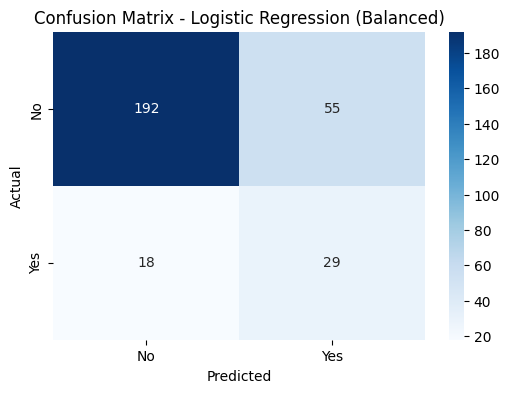

In [ ]:
# Train Logistic Regression Model WITH class_weight='balanced' to handle imbalance
lr_model = LogisticRegression(random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Evaluate
lr_metrics, lr_probs = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression')

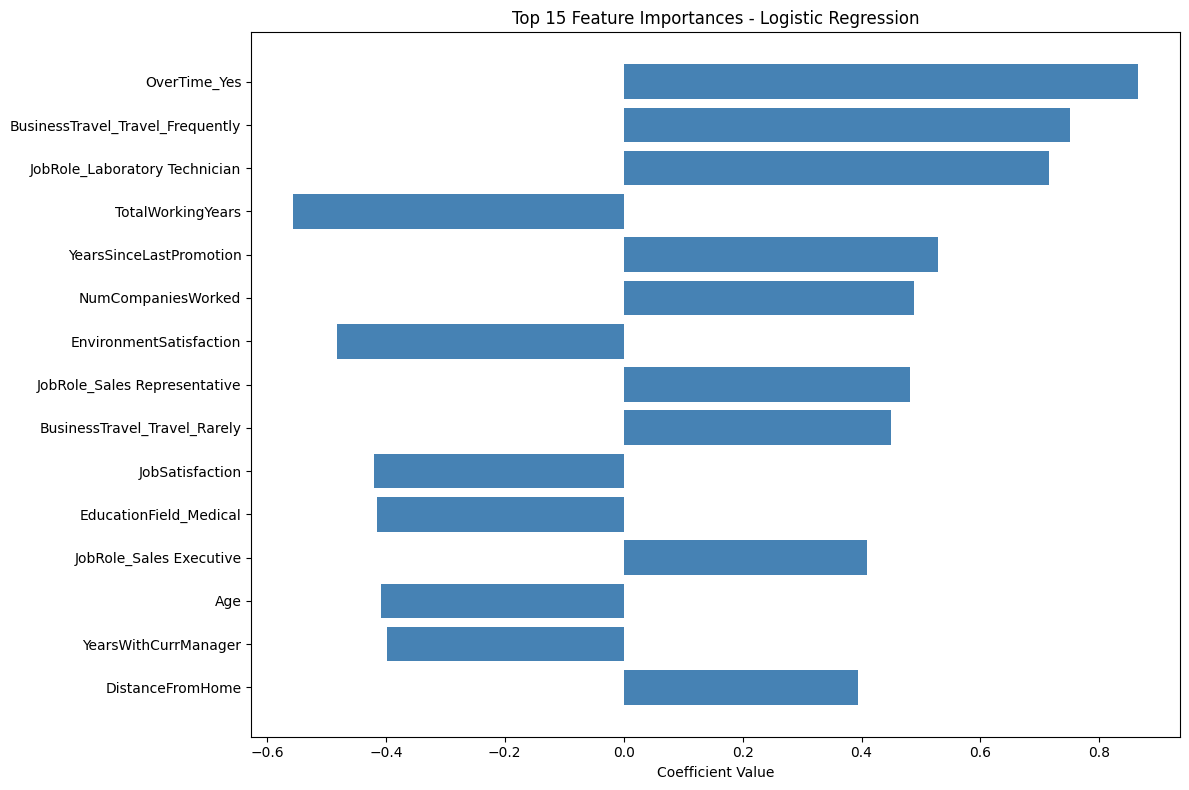

In [80]:
# Feature importance for Logistic Regression (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})
feature_importance_lr['Abs_Coefficient'] = abs(feature_importance_lr['Coefficient'])
feature_importance_lr = feature_importance_lr.sort_values('Abs_Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_lr['Feature'][:15], feature_importance_lr['Coefficient'][:15], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Importances - Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Model 2: K-Nearest Neighbors (KNN)

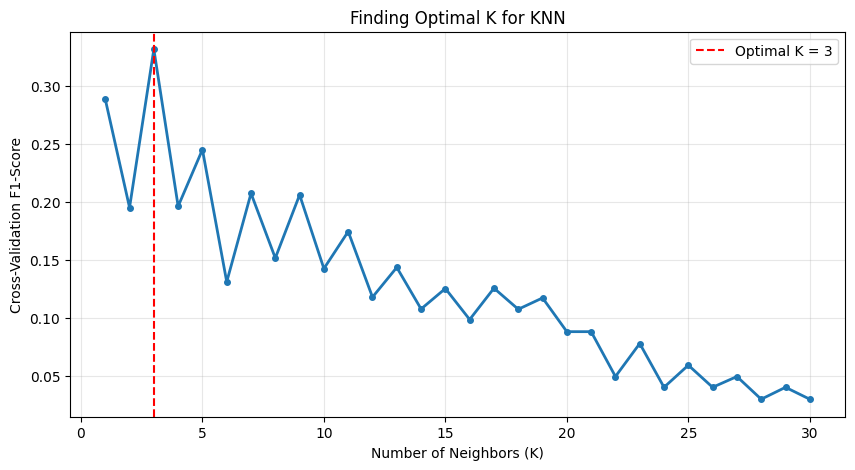

Optimal K: 3 with F1-Score: 0.3312


In [81]:
# Find optimal K using cross-validation
from sklearn.model_selection import cross_val_score

k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    k_scores.append(scores.mean())

# Plot K vs F1-Score
plt.figure(figsize=(10, 5))
plt.plot(k_range, k_scores, marker='o', linewidth=2, markersize=4)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation F1-Score')
plt.title('Finding Optimal K for KNN')
plt.grid(True, alpha=0.3)

optimal_k = k_range[np.argmax(k_scores)]
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.legend()
plt.show()

print(f"Optimal K: {optimal_k} with F1-Score: {max(k_scores):.4f}")

Before SMOTE: {0: 986, 1: 190}
After SMOTE: {0: 986, 1: 986}

Model: KNN (K=3, SMOTE)

Training Accuracy: 0.9123
Test Accuracy: 0.6837

Classification Report (Test Set):
              precision    recall  f1-score   support

No Attrition       0.90      0.70      0.79       247
   Attrition       0.27      0.57      0.37        47

    accuracy                           0.68       294
   macro avg       0.58      0.64      0.58       294
weighted avg       0.80      0.68      0.72       294



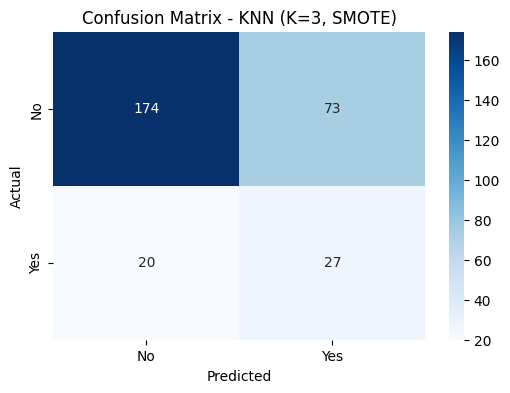

In [ ]:
# Train KNN with optimal K
# Note: KNN doesn't have class_weight parameter, so we use SMOTE for oversampling minority class
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_smote).value_counts().to_dict()}")

knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_train_smote, y_train_smote)

# Evaluate
knn_metrics, knn_probs = evaluate_model(knn_model, X_test_scaled, y_test, f'KNN (K={optimal_k})')

## 5. Model 3: Decision Tree

In [83]:
# First, let's see the effect of max_depth on overfitting
from sklearn.model_selection import GridSearchCV

# Train a basic decision tree (no constraints - likely to overfit)
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train, y_train)

print("Basic Decision Tree (No Constraints):")
print(f"Training Accuracy: {dt_basic.score(X_train, y_train):.4f}")
print(f"Test Accuracy: {dt_basic.score(X_test, y_test):.4f}")
print(f"Tree Depth: {dt_basic.get_depth()}")
print(f"Number of Leaves: {dt_basic.get_n_leaves()}")
print("\nNote: High training accuracy but lower test accuracy indicates OVERFITTING!")

Basic Decision Tree (No Constraints):
Training Accuracy: 1.0000
Test Accuracy: 0.7653
Tree Depth: 18
Number of Leaves: 139

Note: High training accuracy but lower test accuracy indicates OVERFITTING!


In [96]:
# Find optimal hyperparameters using GridSearchCV WITH class_weight='balanced'
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),  # Added class_weight
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Best Cross-Validation F1-Score: {dt_grid.best_score_:.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best Cross-Validation F1-Score: 0.3922



Model: Decision Tree (Balanced)

Training Accuracy: 0.7126
Test Accuracy: 0.7279

Classification Report (Test Set):
              precision    recall  f1-score   support

No Attrition       0.92      0.74      0.82       247
   Attrition       0.32      0.64      0.43        47

    accuracy                           0.73       294
   macro avg       0.62      0.69      0.62       294
weighted avg       0.82      0.73      0.76       294



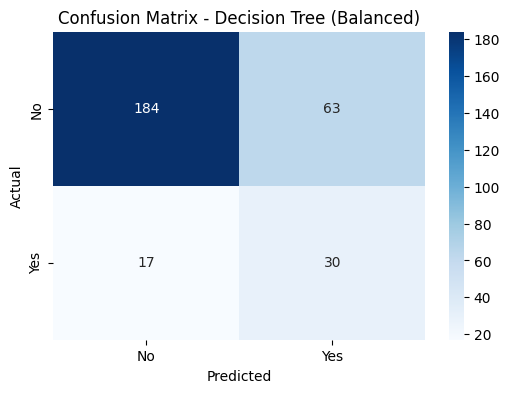

In [ ]:
# Train Decision Tree with best parameters
dt_model = dt_grid.best_estimator_

# Evaluate
dt_metrics, dt_probs = evaluate_model(dt_model, X_test, y_test, 'Decision Tree')

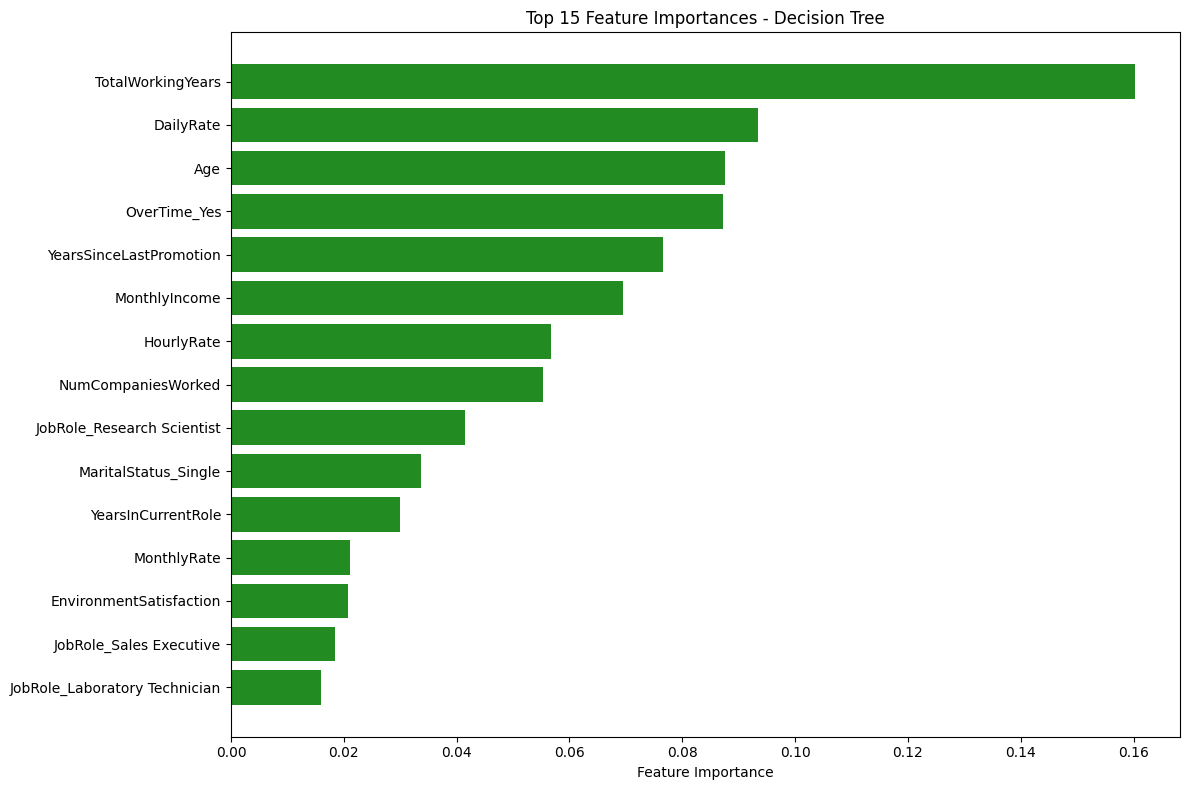


Top 10 Important Features:
                   Feature  Importance
         TotalWorkingYears    0.160211
                 DailyRate    0.093367
                       Age    0.087543
              OverTime_Yes    0.087170
   YearsSinceLastPromotion    0.076586
             MonthlyIncome    0.069540
                HourlyRate    0.056643
        NumCompaniesWorked    0.055242
JobRole_Research Scientist    0.041473
      MaritalStatus_Single    0.033759


In [86]:
# Feature Importance for Decision Tree
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_dt['Feature'][:15], feature_importance_dt['Importance'][:15], color='forestgreen')
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Important Features:")
print(feature_importance_dt.head(10).to_string(index=False))

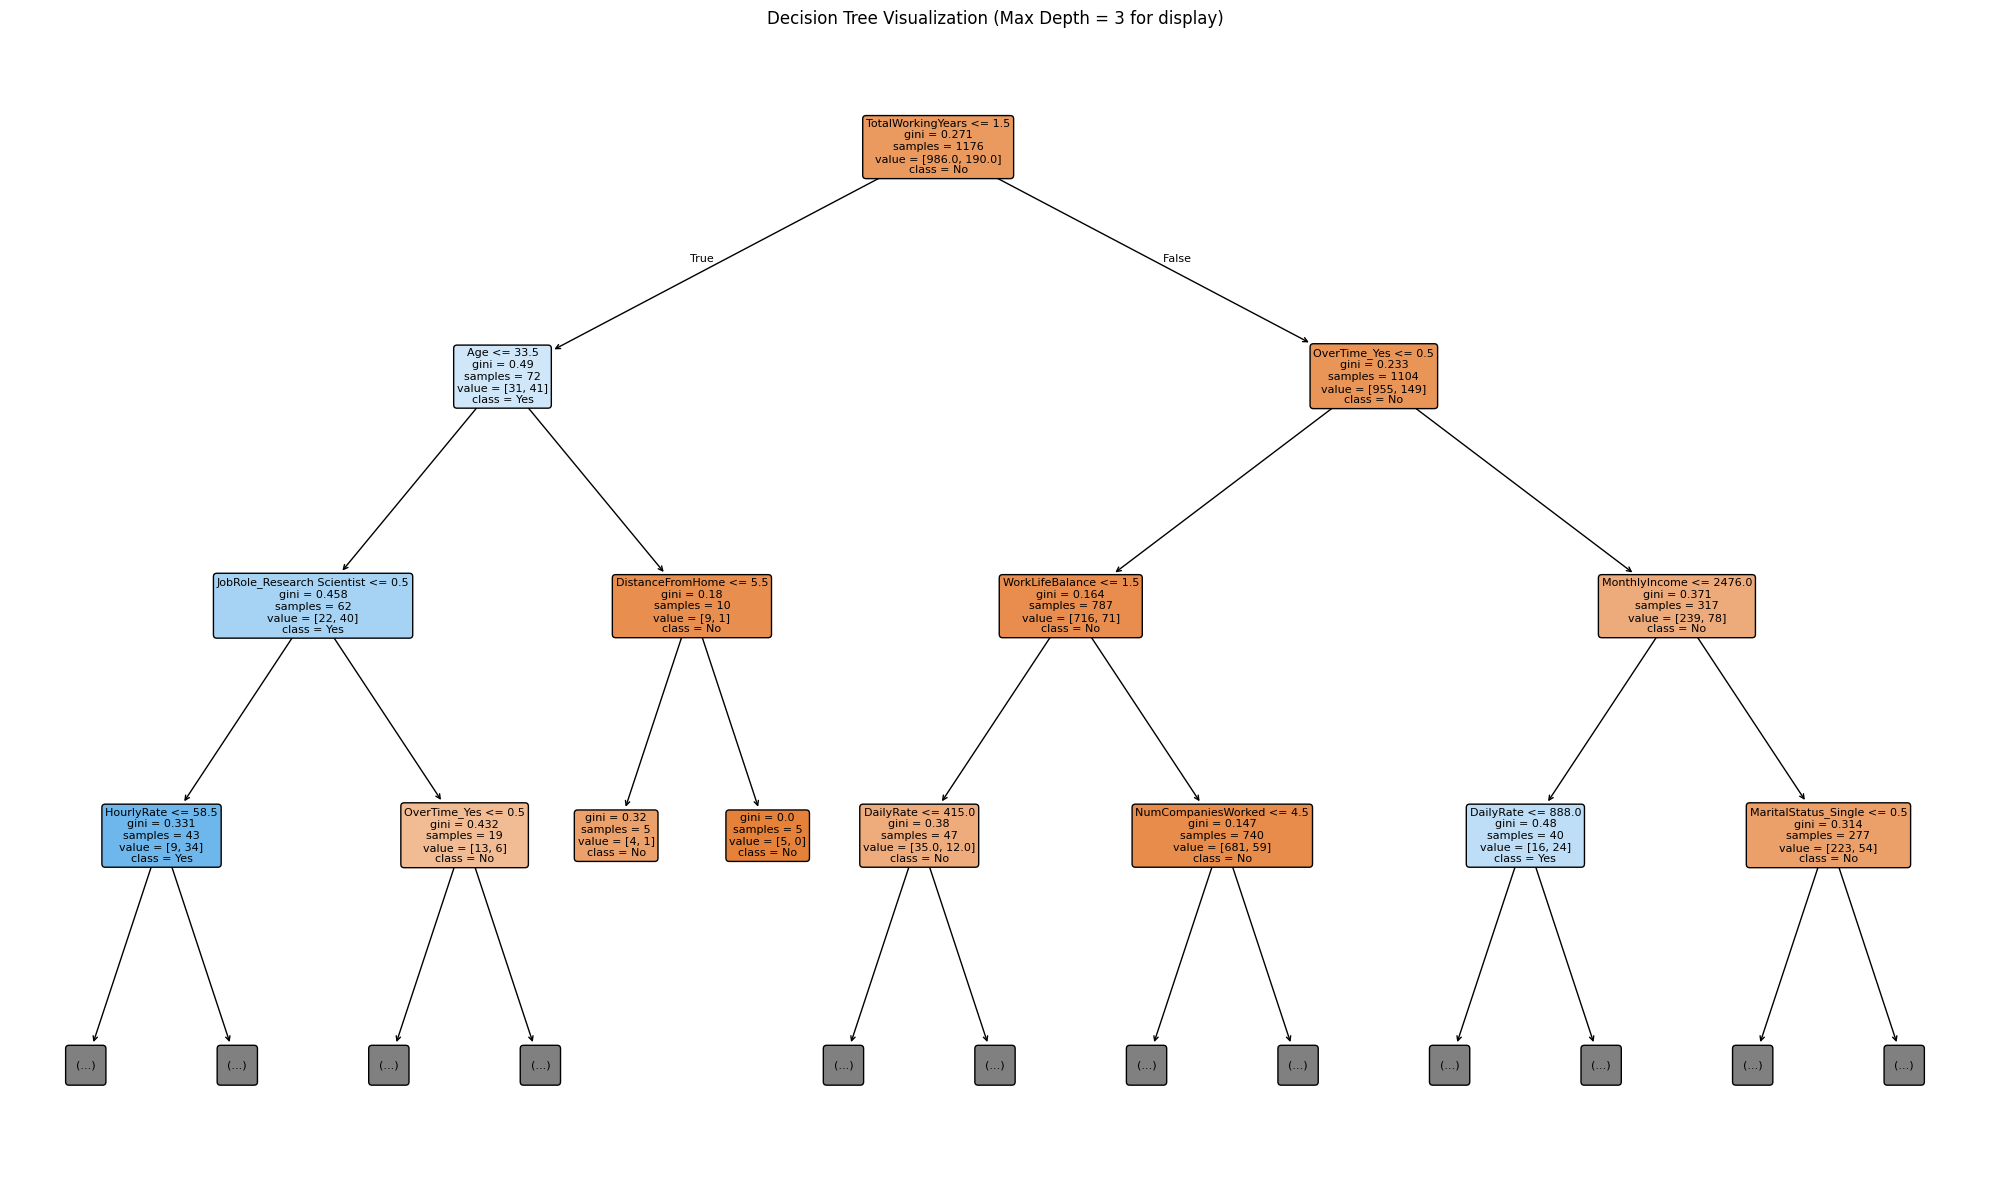

In [87]:
# Visualize the Decision Tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['No', 'Yes'],
          filled=True, 
          rounded=True,
          fontsize=8,
          max_depth=3)  # Limit depth for readability
plt.title('Decision Tree Visualization (Max Depth = 3 for display)')
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [98]:
# Create comparison dataframe
comparison_df = pd.DataFrame([lr_metrics, knn_metrics, dt_metrics])
comparison_df = comparison_df.set_index('Model')

# Display comparison table
print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(comparison_df.round(4).to_string())
print("="*80)

MODEL COMPARISON SUMMARY
                                Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                                              
Logistic Regression (Balanced)          0.7789         0.7517     0.3452  0.6170    0.4427   0.7983
KNN (K=3, SMOTE)                        0.9123         0.6837     0.2700  0.5745    0.3673   0.6247
Decision Tree (Balanced)                0.7126         0.7279     0.3226  0.6383    0.4286   0.6956


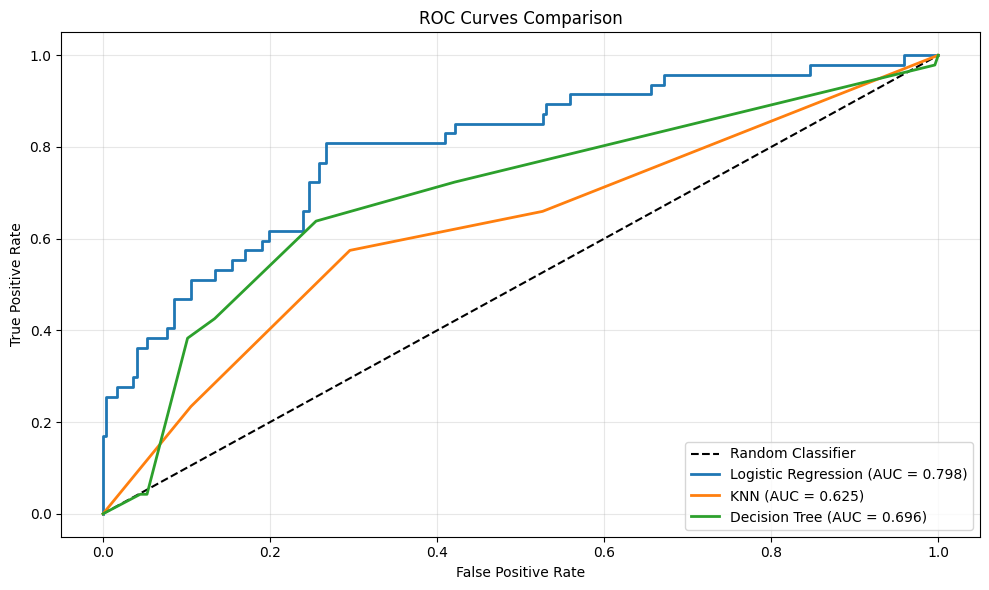

In [111]:
# ROC Curves Comparison
plt.figure(figsize=(10, 6))

# Random Classifier baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.3f})', linewidth=2)

# KNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_metrics["ROC-AUC"]:.3f})', linewidth=2)

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_metrics["ROC-AUC"]:.3f})', linewidth=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()